<a href="https://colab.research.google.com/github/fvelascor/MCDIA/blob/master/Hands_On_Introducci%C3%B3n_a_la_Estad%C3%ADstica_Inferencial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **HANDS ON: INTRODUCCIÓN A ESTADÍSTICA INFERENCIAL**

Una vez visto la presentación ***Introducción a la estadística inferencial***, se proporciona el siguiente ***colab*** para que **el alumnado pueda practicar** haciendo uso del lenguaje de programación ***python***.

De igual manera, se proporciona la **solución** de este notebook a través del siguiente [enlace](https://colab.research.google.com/drive/1wBQxgzbO4PV0meYNF_UCzhk7p6yC_xGu?usp=sharing).


## **PRUEBA DE HIPÓTESIS**

La **prueba de hipótesis** es un procedimiento formal dentro de la estadística inferencial que se usa para aceptar o rechazar una afirmación sobre un parámetro poblacional. Se basa en comparar dos hipótesis opuestas: la nula ($H_0$) y la alternativa ($H_1$).

***NOTA:*** *Se hará el uso de las bibliotecas de **Pandas**, **Seaborn** y **Scipy** para usar datasets precargados y operaciones estadísticas sin entrar a tanto detalle a las librerías mismas. Para ello, se explicará mas a detalle en el siguiente módulo.*

In [30]:
# Importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [31]:
# Importar dataset
df = sns.load_dataset("tips")

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### **NIVEL DE SIGNIFICANCIA:**

Es el umbral de error que estamos dispuestos a aceptar. Comúnmente se utiliza **$\alpha = 0.01, 0.05, 0.1$** representando el 1%, 5%, y 10% de nivel de significancia correspondientemente.

* Si el **p-value < $\alpha$**: Rechazamos $H_0$ (Hay evidencia estadística).

* Si el **p-value > $\alpha$**: No podemos rechazar $H_0$ (No hay suficiente evidencia).

In [32]:
# Importar módulo
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

**Caso práctico:** ¿Existe una diferencia significativa entre la propina que dan los fumadores vs. los no fumadores?

* $H_0$: La media de propinas es igual para ambos grupos.

* $H_1$: La media de propinas es distinta entre fumadores y no fumadores.

In [33]:
# Separaración de grupos
fumadores = df[df["smoker"] == "Yes"]["tip"]
no_fumadores = df[df["smoker"] == "No"]["tip"]

# Verificar tamaños de cada grupo
print("Fumadores:", len(fumadores))
print("No fumadores:", len(no_fumadores))

Fumadores: 93
No fumadores: 151


In [34]:
# Aplicar Prueba T de Student
from scipy import stats

t_stat, p_value = stats.ttest_ind(fumadores, no_fumadores)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 0.09222805186888201
P-value: 0.9265931522244976


In [35]:
# Interpretar resultados
alpha = 0.05

if p_value < alpha:
    print("Se rechaza H0: existe diferencia significativa entre fumadores y no fumadores.")
else:
    print("No se rechaza H0: no existe evidencia suficiente de diferencia significativa.")

No se rechaza H0: no existe evidencia suficiente de diferencia significativa.


## **APRENDIZAJE ESTADÍSTICO**

El **aprendizaje estadístico** es un marco de trabajo que **combina la estadística y la computación** para construir **modelos predictivos o de clasificación** a partir de los datos. Es la base teórica de lo que hoy conocemos como Machine Learning.

### **REGRESIÓN LINEAL SIMPLE:**



Una **regresión lineal simple** es un método estadístico utilizado para modelar la relación entre una variable independiente, el cual actua como una **variable predictora**, y una variable dependiente que actua como una **variable objetivo**.

Su objetivo es encontrar una línea recta que mejor se ajuste a los datos para **predecir un valor objetivo en función del valor predictor**.

Una regresión lineal tiene la forma:

\begin{equation} \overline{y} = β\overline{x} + α  \, \, \, \equiv \, \, \, y = mx + b \end{equation}

Y su función de costo:

\begin{equation} c(x) = \frac{1}{n} Σ_{i=1}^n(\overline{y} - y_i)² \end{equation}

In [36]:
# Definir regresión lineal

from sklearn.linear_model import LinearRegression

X = df[["total_bill"]]   # variable independiente
y = df["tip"]            # variable dependiente

# Crear modelo
modelo = LinearRegression()

In [37]:
# Predicción de valores con regresión lineal
# Entrenar el modelo
modelo.fit(X, y)

# Realizar predicciones
y_pred = modelo.predict(X)

# Mostrar primeras predicciones
y_pred[:10]

array([2.70463616, 2.00622312, 3.12683472, 3.40725019, 3.5028225 ,
       3.57633966, 1.84133463, 3.74332864, 2.49983836, 2.47253198])

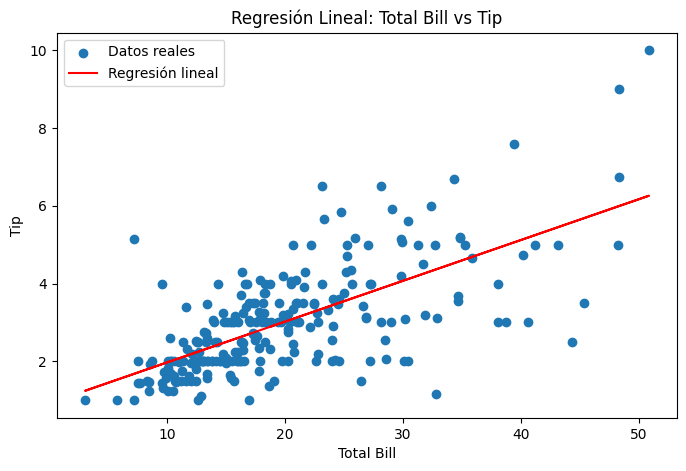

In [38]:
# Visualizar regresión lineal

plt.figure(figsize=(8,5))

# Puntos reales
plt.scatter(X, y, label="Datos reales")

# Línea de regresión
plt.plot(X, y_pred, color="red", label="Regresión lineal")

plt.title("Regresión Lineal: Total Bill vs Tip")
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.legend()
plt.show()

In [39]:
# Iterar pérdida de la regresión lineal
import numpy as np

# Calcular función de costo (MSE)
mse = np.mean((y - y_pred) ** 2)

print("Error cuadrático medio (MSE):", mse)

Error cuadrático medio (MSE): 1.036019442011377


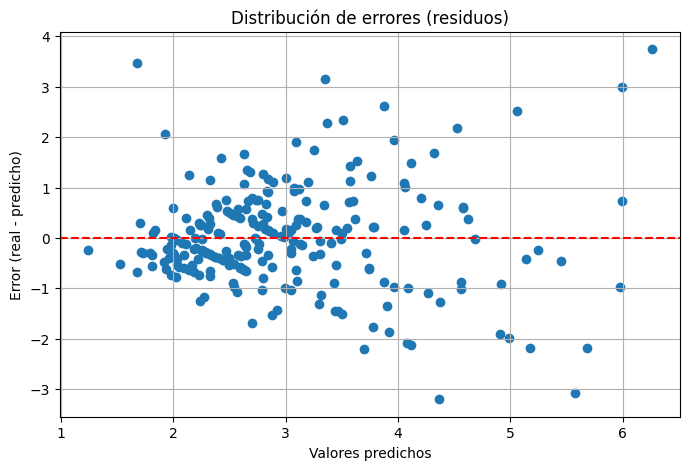

In [40]:
# Visualizar pérdida de la regresión lineal
errores = y - y_pred

plt.figure(figsize=(8,5))

# Errores como dispersión respecto a 0
plt.scatter(y_pred, errores)

# Línea de referencia en 0
plt.axhline(y=0, color="red", linestyle="--")

plt.title("Distribución de errores (residuos)")
plt.xlabel("Valores predichos")
plt.ylabel("Error (real - predicho)")
plt.grid(True)

plt.show()


### **DESCENSO DE GRADIENTE:**

El **descenso de gradiente** es un algoritmo de optimización ampliamente utilizado en el campo del aprendizaje automático y en la resolución numérica de problemas de optimización.

Su objetivo principal es encontrar el **mínimo de una función**, lo que es esencial en la optimización de modelos y la resolución de problemas matemáticos, para ajustar los parámetros de manera que la **función de costo se minimice**.

El descenso de gradiente tiene la forma:

\begin{equation} (ϴ_0, ϴ_1)_{i+1} = (ϴ_0, ϴ_1)_i - α * \frac{∂\,\,c(ϴ_0, ϴ_1)}{∂(ϴ_0, ϴ_1)} \, \, \,\, \, \,\, \, \, ; \, \, \,\, \, \,\, \, \, α \in (0, 1) \end{equation}

Donde su predicción:

\begin{equation} h_ϴ(x) = ϴ_1x + ϴ_0  \, \, \, \equiv \, \, \, y = mx + b \end{equation}


In [41]:
# Definir parámetros
import numpy as np

# Parámetros iniciales (θ0 = intercepto, θ1 = pendiente)
theta0 = 0
theta1 = 0

# Tasa de aprendizaje (α)
alpha = 0.01

# Número de iteraciones
epochs = 1000

La función de costo tiene la forma:

\begin{equation} c(ϴ_0, ϴ_1) = \frac{1}{n} Σ_{i=1}^n(h_ϴ(x_i) - y_i)² \end{equation}

Al derivar función de costo:

*   Parámetro 1:

\begin{equation} \frac{∂}{∂(ϴ_0)}\ c(ϴ_0, ϴ_1) =  \frac{2}{n} Σ_{i=1}^n(h_ϴ(x_i) - y_i) \end{equation}


*   Paramétro 2:

\begin{equation} \frac{∂}{∂(ϴ_1)}\ c(ϴ_0, ϴ_1) =  \frac{2}{n} Σ_{i=1}^n(h_ϴ(x_i) - y_i)(x_i) \end{equation}

In [42]:
# Realizar algoritmo del descenso de gradiente
n = len(X)

theta0 = 0
theta1 = 0
alpha = 0.01
epochs = 1000

# Convertir X a array
X_vals = X.values.reshape(-1)
y_vals = y.values

for i in range(epochs):

    # Predicción del modelo
    y_pred = theta1 * X_vals + theta0

    # Error
    error = y_pred - y_vals

    # Derivadas parciales
    d_theta0 = (2/n) * np.sum(error)
    d_theta1 = (2/n) * np.sum(error * X_vals)

    # Actualización de parámetros
    theta0 = theta0 - alpha * d_theta0
    theta1 = theta1 - alpha * d_theta1

print("Theta0 (intercepto):", theta0)
print("Theta1 (pendiente):", theta1)

Theta0 (intercepto): nan
Theta1 (pendiente): nan


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipykernel_2643/1545400896.py:27: RuntimeWarning: invalid value encountered in scalar subtract
  theta1 = theta1 - alpha * d_theta1


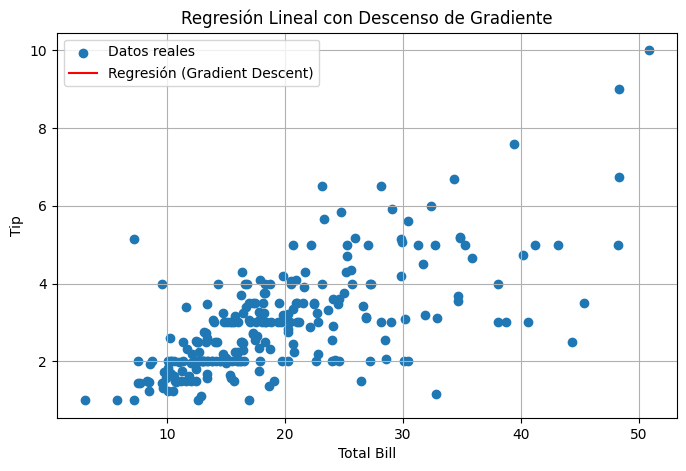

In [43]:
# Visualizar la regresión lineal por descenso de gradiente
plt.figure(figsize=(8,5))

# Datos reales
plt.scatter(X_vals, y_vals, label="Datos reales")

# Línea de regresión (descenso de gradiente)
y_pred_gd = theta1 * X_vals + theta0

plt.plot(X_vals, y_pred_gd, color="red", label="Regresión (Gradient Descent)")

plt.title("Regresión Lineal con Descenso de Gradiente")
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.legend()
plt.grid(True)

plt.show()

In [44]:
# Predicción de valores con descenso de gradiente
y_pred_gd = theta1 * X_vals + theta0

# Mostrar primeras predicciones
y_pred_gd[:10]

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan])

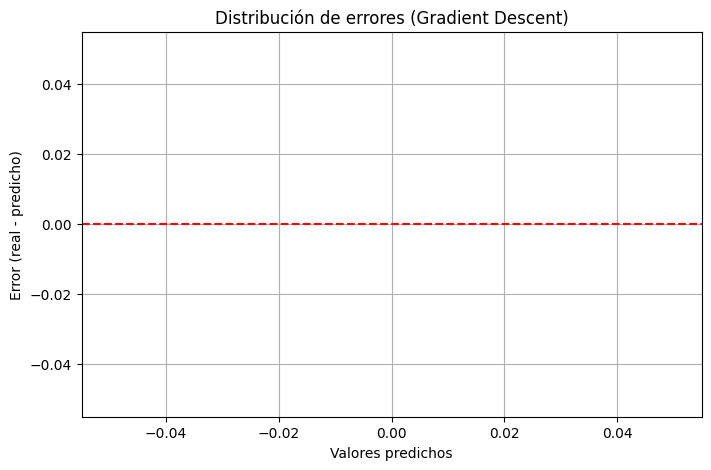

In [45]:
# Visualizar las pérdidas
errores_gd = y_vals - y_pred_gd

plt.figure(figsize=(8,5))

# Dispersión de errores
plt.scatter(y_pred_gd, errores_gd)

# Línea de referencia en 0
plt.axhline(y=0, color="red", linestyle="--")

plt.title("Distribución de errores (Gradient Descent)")
plt.xlabel("Valores predichos")
plt.ylabel("Error (real - predicho)")
plt.grid(True)

plt.show()

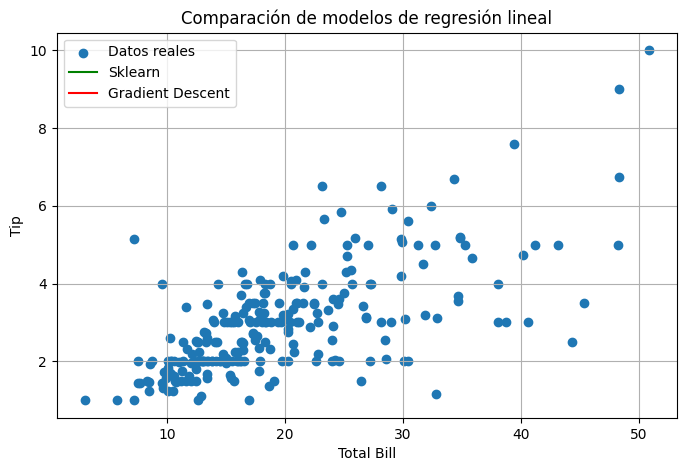

In [46]:
# Comparar las rectas obtenidas por los algoritmos

plt.figure(figsize=(8,5))

# Datos reales
plt.scatter(X_vals, y_vals, label="Datos reales")

# Predicción con sklearn
plt.plot(X_vals, y_pred, color="green", label="Sklearn")

# Predicción con descenso de gradiente
plt.plot(X_vals, y_pred_gd, color="red", label="Gradient Descent")

plt.title("Comparación de modelos de regresión lineal")
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.legend()
plt.grid(True)

plt.show()

## **CHALLENGE: ANÁLISIS PREDICTIVO DE DATOS**

Una vez visto el ***Hands - On: Introducción a la estadística inferencial***, se presentan las siguientes actividades para que el alumnado pueda repasar y reforzar lo aprendido dentro de la clase.

Dentro de la siguiente dinámica, **se realizará un análisis de estadística inferecial** haciendo uso de **operaciones vectorizadas y visualización de datos** a través del **dataset taxis** proveniente de la librería de ***Seaborn***.

Donde los análisis a realizar son:

*   **Prueba de hipótesis**
*   **Aprendizaje estadístico**

**IMPORTANTE:** Para su revisión, **es indispensable que los apartados anteriores se encuentren llenados con el código visto durante la sesión.**

### **INSTRUCCIONES:**

**1. Importa las librerías:** Carga las bibliotecas de Numpy, Pandas, Seaborn y Matplotlib.pyplot.










In [47]:
# Importar librerías
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

**2. Importa el dataset de taxis:** Crea una variable denominada df_taxis donde se importe el dataset taxis.

In [48]:
# Importar dataset
df_taxis = sns.load_dataset("taxis")

# Visualizar primeras filas
df_taxis.head()


,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


**3. Realiza una prueba de hipótesis:** Determina si existe una diferencia significativa entre la distancia recorrida de los taxis color amarillo y verde.

Donde:

   * H0: La media de distancia es igual para ambos colores.
   * H1: La media de distancia es distinta entre colores.

In [49]:
# Importar módulo
from scipy import stats

In [50]:
# Separación de grupos
amarillos = df_taxis[df_taxis["color"] == "yellow"]["distance"]
verdes = df_taxis[df_taxis["color"] == "green"]["distance"]

# Ver tamaño de cada grupo
print("Amarillos:", len(amarillos))
print("Verdes:", len(verdes))

Amarillos: 5451
Verdes: 982


In [51]:
# Aplicar Prueba T de Student

t_stat, p_value = stats.ttest_ind(amarillos, verdes, nan_policy='omit')

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -3.4059875730195217
P-value: 0.0006632881723072262


In [52]:
# Interpretación automática
alpha = 0.05

if p_value < alpha:
    print("Se rechaza H0: existe diferencia significativa en la distancia entre taxis amarillos y verdes.")
else:
    print("No se rechaza H0: no hay evidencia suficiente de diferencia significativa.")

Se rechaza H0: existe diferencia significativa en la distancia entre taxis amarillos y verdes.


**4. Realiza un aprendizaje estadístico:**

   * Crea un modelo de regresión lineal simple para predecir el costo del viaje en función de la distancia recorrida.
   * Ajusta el modelo a través del algoritmo de optimización del descenso de gradiente.
   * Utiliza el modelo ajustado para realizar una predicción de cuánto costará un viaje de dado un valor agregado por el usuario en unidades de distancia.

In [53]:
# Definir regresión lineal
from sklearn.linear_model import LinearRegression

# Variables
X = df_taxis[["distance"]]
y = df_taxis["total"]

# Modelo
modelo = LinearRegression()

In [54]:
# Realizar algoritmo del descenso de gradiente
# Datos
X_vals = df_taxis["distance"].values
y_vals = df_taxis["total"].values

# Parámetros iniciales
theta0 = 0
theta1 = 0

alpha = 0.01
epochs = 1000

n = len(X_vals)

# Entrenamiento
for i in range(epochs):

    y_pred = theta1 * X_vals + theta0
    error = y_pred - y_vals

    d_theta0 = (2/n) * np.sum(error)
    d_theta1 = (2/n) * np.sum(error * X_vals)

    theta0 -= alpha * d_theta0
    theta1 -= alpha * d_theta1

print("Theta0:", theta0)
print("Theta1:", theta1)

Theta0: 8.641877526966756
Theta1: 3.265171183471686


In [55]:
# Predicción de valores con descenso de gradiente
y_pred_gd = theta1 * X_vals + theta0

# Mostrar primeras predicciones
y_pred_gd[:10]

array([13.86615142, 11.22136276, 13.11516205, 33.78369564, 15.69464728,
       10.24181141, 20.55975235, 13.21311718, 20.49444892, 13.60493773])

**5. Visualiza los resultados:**

   * Grafica las líneas de las regresiones para comparar entre la regresión lineal simple y el algoritmo de optimización.
   * Grafica la función de costo resultante del ajuste con el algoritmo de optimización.

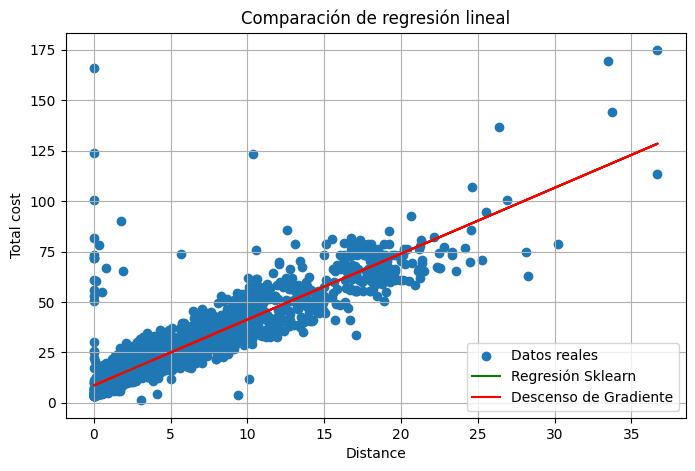

In [56]:
# Visualizar regresiones
from sklearn.linear_model import LinearRegression

# Modelo sklearn
modelo = LinearRegression()
modelo.fit(X, y)
y_pred_sklearn = modelo.predict(X)

plt.figure(figsize=(8,5))

# Datos reales
plt.scatter(X_vals, y_vals, label="Datos reales")

# Regresión sklearn
plt.plot(X_vals, y_pred_sklearn, color="green", label="Regresión Sklearn")

# Regresión descenso de gradiente
plt.plot(X_vals, y_pred_gd, color="red", label="Descenso de Gradiente")

plt.title("Comparación de regresión lineal")
plt.xlabel("Distance")
plt.ylabel("Total cost")
plt.legend()
plt.grid(True)

plt.show()

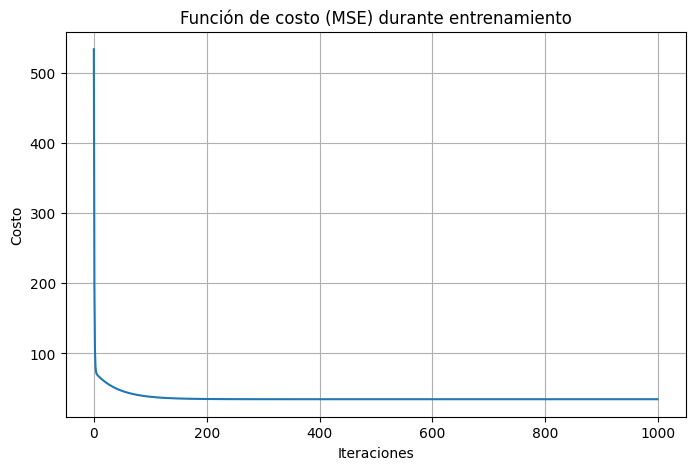

In [57]:
# Visualizar función de costo
cost_history = []

theta0 = 0
theta1 = 0
alpha = 0.01
epochs = 1000

n = len(X_vals)

for i in range(epochs):

    y_pred = theta1 * X_vals + theta0
    error = y_pred - y_vals

    cost = np.mean(error ** 2)
    cost_history.append(cost)

    d_theta0 = (2/n) * np.sum(error)
    d_theta1 = (2/n) * np.sum(error * X_vals)

    theta0 -= alpha * d_theta0
    theta1 -= alpha * d_theta1

plt.figure(figsize=(8,5))
plt.plot(cost_history)

plt.title("Función de costo (MSE) durante entrenamiento")
plt.xlabel("Iteraciones")
plt.ylabel("Costo")
plt.grid(True)

plt.show()